In [2]:
import librosa
from scipy.signal import butter, filtfilt
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
dataset = '../EMOVO/'
actors = ['f1','f2','f3','m1','m2','m3']
files = []

for path in actors:
    actors_paths = dataset + path +'/'
    for file in os.listdir(actors_paths):
        if file.endswith(".wav"):
            files.append(actors_paths + file)

print(len(files))

588


we define a function to resample the audioFiles

In [4]:
def resample_audio(audio_path, ismono = True,  target_sr=22000):
    y, sr = librosa.load(audio_path, mono=ismono, sr=target_sr)
    return y, sr



In [5]:
resampled_files = []
for file in files:
    resampled_files.append(resample_audio(file)[0])

print(len(resampled_files))
resampled_files[0]



588


array([0.00020136, 0.00022677, 0.00037475, ..., 0.00025305, 0.00026525,
       0.00027121], dtype=float32)

now we define a function to reduce noise

In [11]:
#voice is known to be going from 100HZ to 1100HZ
from scipy.signal import butter, sosfilt, sosfreqz
def butter_bandpass(signal, fs, lowcut=100, highcut=1100, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(order, [low, high], btype='band', output='sos')

    return sosfilt(sos, signal)

In [7]:
def plot_frequency(y, sr):
    n = len(y)
    f = np.fft.fftfreq(n, 1/sr)
    Y = np.fft.fft(y)
    plt.plot(f, np.abs(Y))
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude')
    plt.show()


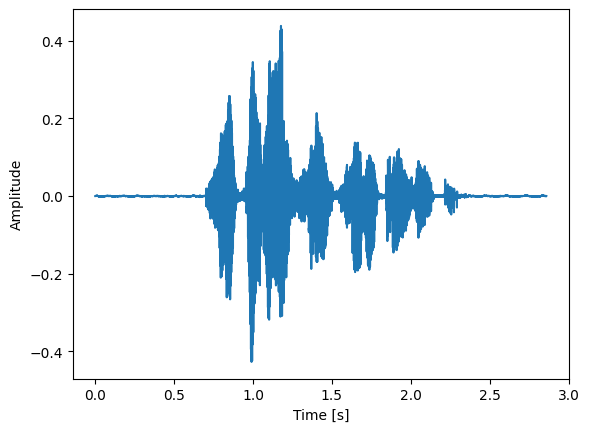

(62891,) (62891,)


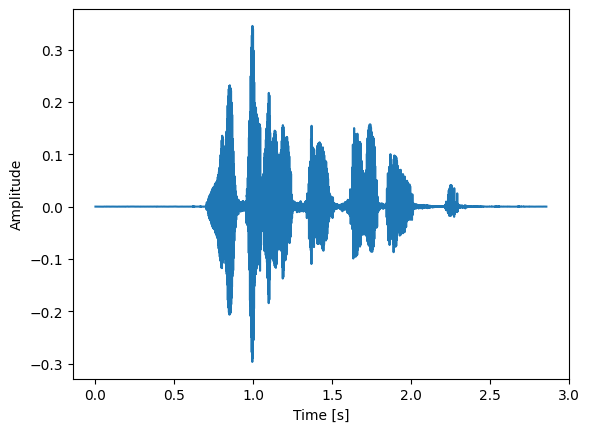

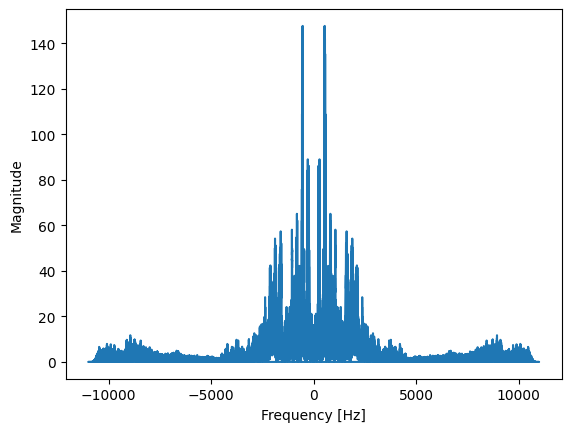

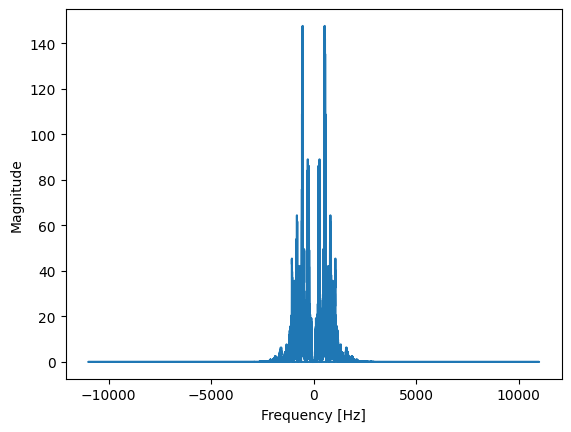

In [14]:
# lets try the function on one audio
fs = 22000
y = resampled_files[0]
t = np.linspace(0, len(y)/fs, len(y))
plt.plot(t, y)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()
y_butter_filter = butter_bandpass(y, fs, lowcut=100, highcut=1100, order=5)
print(y_butter_filter.shape, y.shape)
plt.plot(t, y_butter_filter)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()
plot_frequency(y, fs)
plot_frequency(y_butter_filter, fs)

#let's hear the difference
import sounddevice as sd
sd.play(y, fs)
sd.wait()
sd.play(y_butter_filter, fs)


In [9]:
#now let's design a function that apply chebyshev filter in order to remove the noise
from scipy.signal import cheby1, sosfilt

def apply_chebyshev_filter(signal, fs, lowcut=100, highcut=1100, order=5, rp=5):
    low = lowcut / (0.5 * fs)
    high = highcut / (0.5 * fs)
    
    # Applica il filtro di Chebyshev
    sos = cheby1(order, rp, [low, high], btype='band', output='sos')
    filtered_signal = sosfilt(sos, signal)
    
    return filtered_signal



(62891,) (62891,)


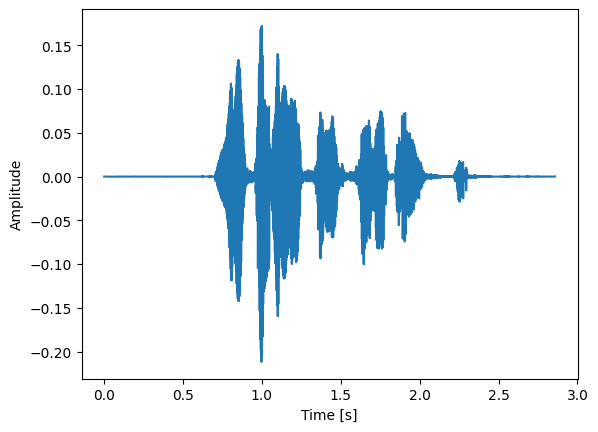

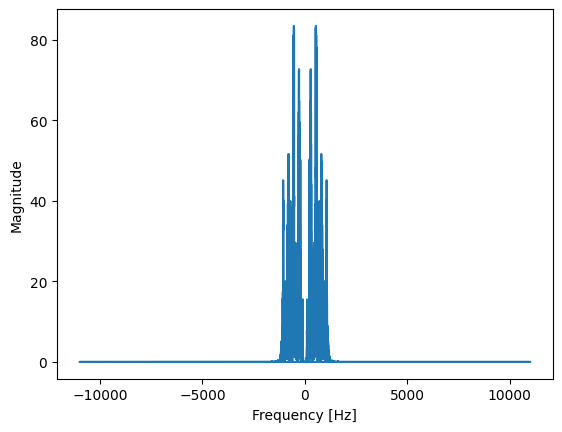

In [18]:
y_butter_chebyshev_filter = apply_chebyshev_filter(y_butter_filter, fs)
print(y_butter_chebyshev_filter.shape, y_butter_filter.shape)
plt.plot(t, y_butter_chebyshev_filter)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()
plot_frequency(y_butter_chebyshev_filter, fs)
sd.play(y_butter_filter, fs)
sd.wait()
sd.play(y_butter_chebyshev_filter, fs)



In [ ]:
#let's uniform the length of the audio files
